In [2]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [3]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AFC986DA30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AFC988E3C0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### **First Graph**

#### Step 1: Define the schema

In [4]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]

#### Step 2: Create Node functions

In [5]:
def welcome(state:graph_schema) -> graph_schema:
    curr_message = state['messages']

    response = llm.invoke(curr_message).content

    state['messages'] = f"Your message was: {curr_message}. Here's my response: {response}"

    return state

#### Step 3: Create the state graph

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("Welcome", welcome)

graph.add_edge(START, "Welcome")
graph.add_edge("Welcome", END)

#### Step 4: Compile the graph with checkpoint

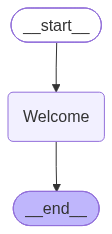

In [7]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpoint = InMemorySaver()

memory_graph = graph.compile(checkpointer=checkpoint)
Image(memory_graph.get_graph().draw_mermaid_png())

#### Step 4: Invoke the graph with config

In [12]:
response = memory_graph.invoke({"messages":"My name is Balaji"}, {"configurable":{"thread_id":"Tammireddy"}})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

My name is Balaji
================================ Human Message =================================

Your message was: [HumanMessage(content='My name is Balaji', additional_kwargs={}, response_metadata={}, id='51804cf2-8a45-42f2-a3e3-9c04984cedd8')]. Here's my response: Nice to meet you, Balaji! How can I assist you today?
================================ Human Message =================================

My name is Balaji
================================ Human Message =================================

Your message was: [HumanMessage(content='My name is Balaji', additional_kwargs={}, response_metadata={}, id='51804cf2-8a45-42f2-a3e3-9c04984cedd8'), HumanMessage(content="Your message was: [HumanMessage(content='My name is Balaji', additional_kwargs={}, response_metadata={}, id='51804cf2-8a45-42f2-a3e3-9c04984cedd8')]. Here's my response: Nice to meet you, Balaji! How can I assist you today?", additional_kwar